# Comment Category Prediction Challenge

This dataset provides insight into how an online platform processes and categorizes user-generated comments. Each record represents a single comment and includes metadata such as interaction feedback, symbolic expressions, topic reference indicators, and internal system signals.

So, the task is to explore this dataset and build predictive models that can accurately determine the final category assigned to each comment. Apply your analytical and modeling skills to uncover patterns across textual, numerical, and categorical features.

# Setup & Imports

In [1]:
## Utilities
import os, sys, threading, time
import string, re
import joblib, gc

## Big Data Libraries
import numpy as np
import pandas as pd

## Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

## Pre-processing & Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline, Pipeline, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

## Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, r2_score, f1_score,
    mean_squared_error
)

## Models
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

## HPT
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

import warnings
warnings.filterwarnings("ignore")

# Plotting defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

## Print the absolute paths of the available input files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


## Utility functions

- `Timer`: A small helper class that wraps any block of code in a context manager and reports elapsed wall-clock time. This is useful for monitoring how long training and inference steps take.
- `print_distribution`: A function to pritty print the class distributions.

In [2]:
## A Function to keep record of the time taken by a process
class Timer:
    def __init__(self, name=None, verbose=True, interval=1):
        self.name, self.verbose, self.interval = name, verbose, interval
        self._start = self.elapsed = None
        self._running = False

    def _label(self):
        return f"[{self.name}] " if self.name else ""

    def _fmt(self, t):
        h, m = divmod(int(t), 3600)
        m, s = divmod(m, 60)
        parts = ([f"{h}h"] if h else []) + ([f"{m}m"] if m or h else []) + [f"{s + (t-int(t)):.2f}s"]
        return " ".join(parts)

    def _loop(self):
        while self._running:
            t = time.perf_counter() - self._start
            sys.stdout.write(f"\r{self._label()}Running ({self._fmt(t)})...")
            sys.stdout.flush()
            time.sleep(self.interval)

    def start(self, name=None):
        if name: self.name = name
        self._start, self._running = time.perf_counter(), True
        if self.verbose:
            threading.Thread(target=self._loop, daemon=True).start()
        return self

    def stop(self):
        if self._start is None:
            raise RuntimeError("Timer not started")
        self.elapsed, self._running = time.perf_counter() - self._start, False
        if self.verbose:
            sys.stdout.write(f"\r{self._label()}Time taken: {self._fmt(self.elapsed)}\n")
        return self.elapsed

    def __enter__(self): return self.start()
    def __exit__(self, *exc): self.stop()

timer = Timer()

In [3]:
## Function to print distribution of labels in a dataset
def print_distribution(X, y, title, total_width=60, bar_width=44):
    print(f"{title:<30} {f'Shape: {X.shape}':>29}")
    print("=" * total_width)
    print("Distribution of labels:\n")
    print(
        *(f"{l:<5} {c:06.2%}  "f"[{'=' * int(c * bar_width)}{' ' * (bar_width - int(c * bar_width))}]"
            for l, c in y.value_counts(normalize=True).sort_index().items()),
        sep="\n"
    )

## Data Loading & Overview

The dataset consists of the following files:

- `train.csv`: The training set, including the target variable label along with all feature columns.
- `test.csv`: The test set, containing the same feature columns but excluding the target variable label.
- `sample_submission.csv`: A sample submission file provided in the correct format for competition submissions.

In [4]:
## Load the Datasets

train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

## Shapes
print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

Train Dataset Shape: (198000, 15)
Test Dataset Shape: (102000, 14)


## Columns Description

| Column | Description |
|---|---|
| `comment` | Raw text content of the comment |
| `created_date` | Timestamp when the comment was posted |
| `post_id` | Unique ID linking the comment to its parent discussion thread |
| `emoticon_1/2/3` | Indicators for the presence of symbols from three internal emoticon groups |
| `upvote` | Number of positive reactions received |
| `downvote` | Number of negative reactions received |
| `if_1`, `if_2` | Hidden internal platform features |
| `race` | Whether the system detected references to a specific group identity |
| `religion` | Whether the system detected references to a belief-related topic |
| `gender` | Whether the system detected references to a gender-related topic |
| `disability` | Whether the system detected references to an ability-related topic |
| `label` | Target variable — one of four internal handling categories |

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


# Exploratory Data Analysis (EDA)

## Missing Value Analysis

We first check for missing values in both the training and test datasets to understand whether any preprocessing or imputation is required before model training.

In [6]:
## Missing Values

print("Missing Values in Train Dataset:")
print(train_df.isna().sum()[train_df.isna().sum() != 0])
print()
print("Missing Values in Test Dataset:")
print(test_df.isna().sum()[test_df.isna().sum() != 0])

Missing Values in Train Dataset:
race        145423
religion    145423
gender      145423
comment          1
dtype: int64

Missing Values in Test Dataset:
race        75269
religion    75269
gender      75269
dtype: int64


From the results, we observe the following:
- The `comment` column contains only one missing value in the training dataset.
- The identity-related columns (`race`, `religion`, `gender`) contain a very large number of missing values in both training and test datasets.

The single missing value in the `comment` column is negligible compared to the total dataset size (~198k rows). Since textual content is the primary feature for this task, imputing this value could introduce artificial noise. Therefore, it is reasonable to drop this single row without affecting the dataset distribution.

In [7]:
print("Unique Values in `race`    : ", train_df['race'].dropna().unique())
print("Unique Values in `religion`: ", train_df['religion'].dropna().unique())
print("Unique Values in `gender`  : ", train_df['gender'].dropna().unique())

Unique Values in `race`    :  ['none' 'white' 'other' 'asian' 'black' 'latino']
Unique Values in `religion`:  ['christian' 'muslim' 'none' 'jewish' 'atheist' 'other' 'hindu' 'buddhist']
Unique Values in `gender`  :  ['none' 'male' 'female' 'transgender' 'other']


However, the situation is very different for the identity-related columns:
- `race`, `religion`, and `gender` contain tens of thousands of missing entries.
- Removing rows with missing values in these columns would lead to significant data loss, which is undesirable.

To understand the nature of these missing values, we inspect the unique values present in each column.

The unique values show that each column already contains a category labeled `"none"`, indicating that the comment does not reference that identity group.

This suggests that the missing values likely represent the absence of identity references, rather than unknown or corrupted data. In other words, a missing value semantically behaves similarly to `"none"`.

In [8]:
## Drop the missing Comment in Train Dataset
train_df = train_df.dropna(subset=['comment']).reset_index(drop=True)

## Impute the missing values in 'race', 'religion', 'gender'
train_df[['race', 'religion', 'gender']] = train_df[['race', 'religion', 'gender']].fillna('none')
test_df[['race', 'religion', 'gender']] = test_df[['race', 'religion', 'gender']].fillna('none')

## Convert 'disability' from Boolean to Integer (False -> 0; True -> 1)
train_df['disability'] = train_df['disability'].astype(int)
test_df['disability'] = test_df['disability'].astype(int)

## Identity Features Analysis

We now examine the distribution of identity-related indicators in both the training and test datasets. The features analyzed are:
- `race`
- `religion`
- `gender`
- `disability`

These attributes indicate whether a comment references a particular identity group. The bar plots below compare the distribution of these features across the training and test datasets.

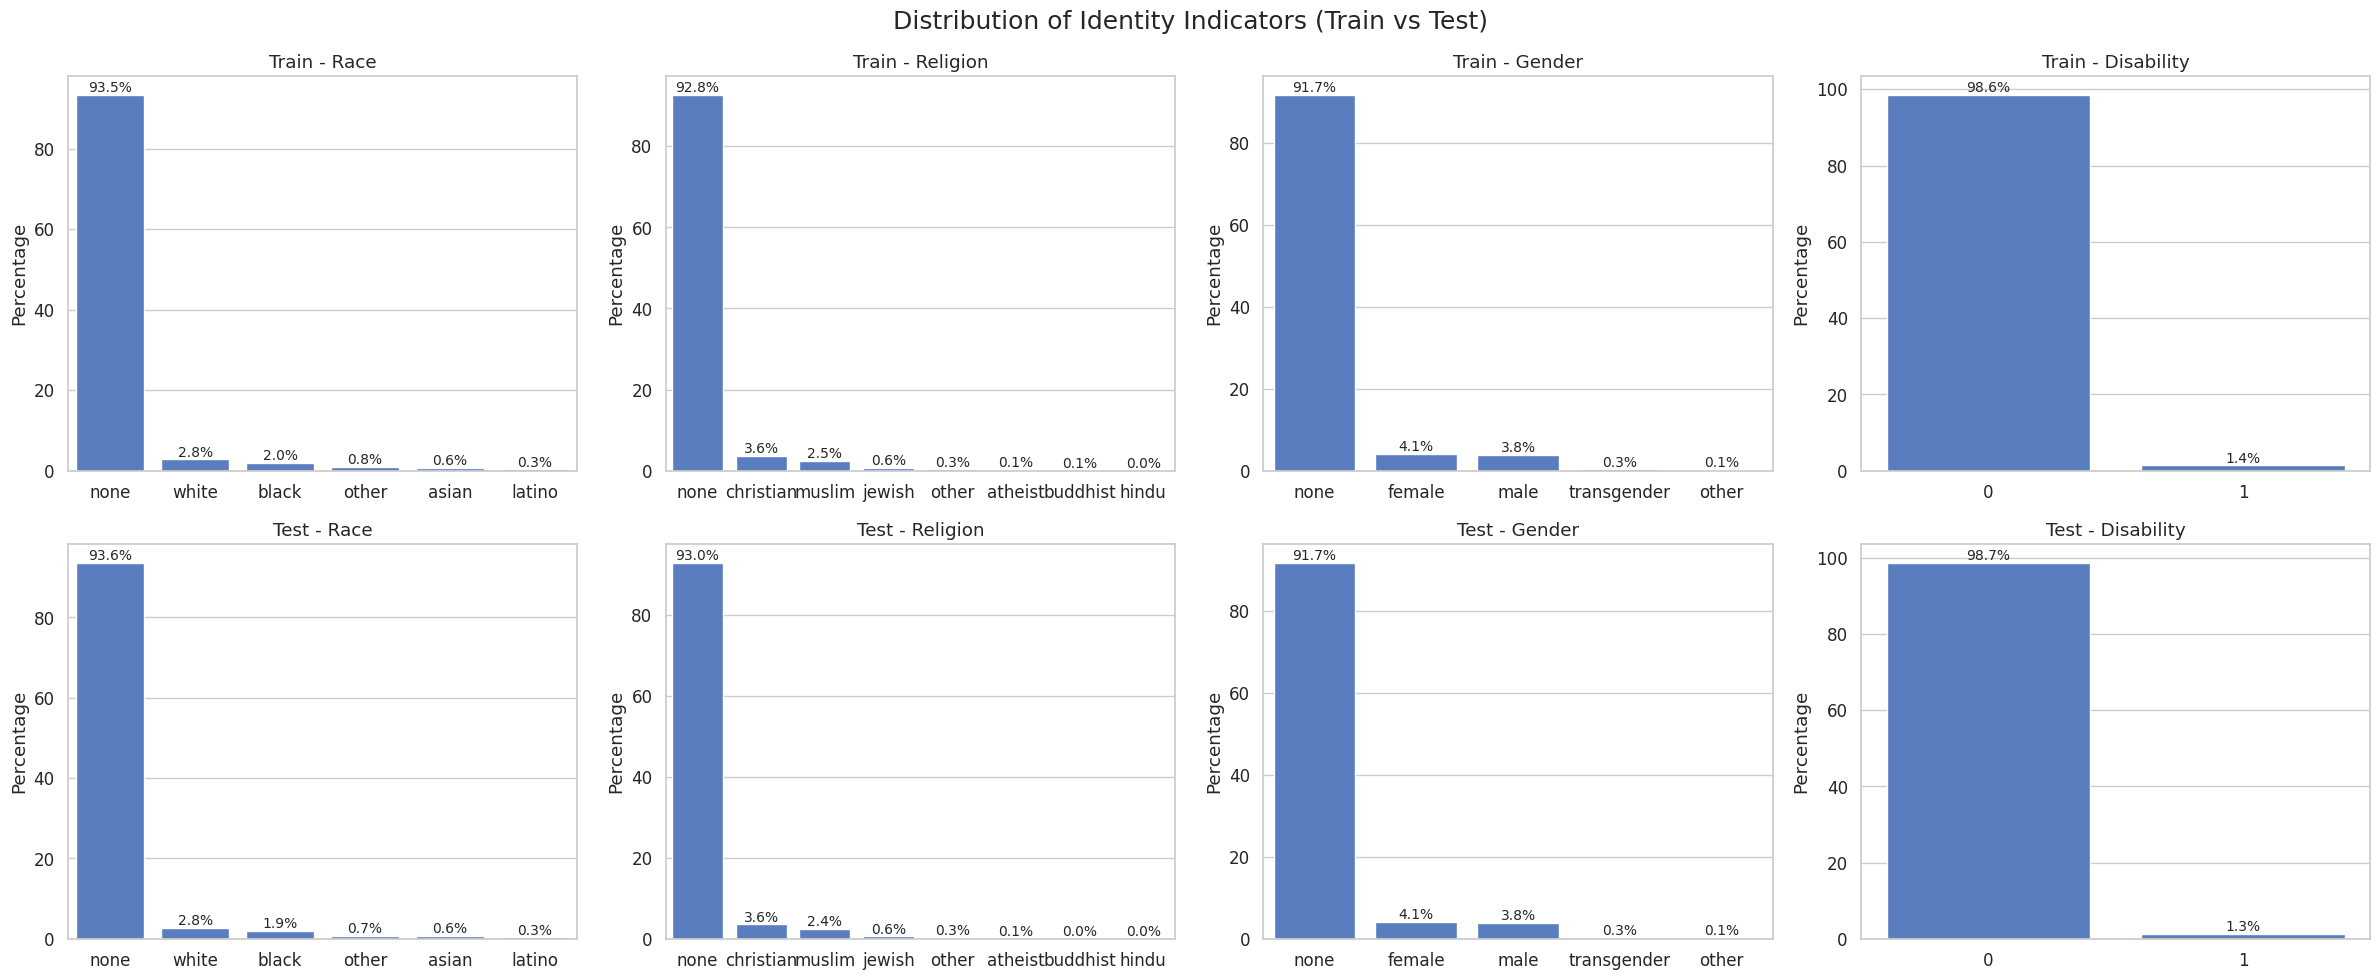

In [9]:
## Distribution of 'race', 'religion', 'gender', 'disability'
cols = ['race', 'religion', 'gender', 'disability']
datasets = [("Train", train_df), ("Test", test_df)]

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("Distribution of Identity Indicators (Train vs Test)", fontsize=18)

for row_idx, (name, df) in enumerate(datasets):
    for col_idx, col in enumerate(cols):
        ax = axes[row_idx, col_idx]
        # Get percentage distribution
        pct = df[col].value_counts(normalize=True) * 100
        
        sns.barplot(
            x=pct.index.astype(str),
            y=pct.values,
            ax=ax
        )
        ax.set_title(f"{name} - {col.capitalize()}")
        ax.set_ylabel("Percentage")
        ax.set_xlabel("")
        # Add percentage labels
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f"{height:.1f}%",
                        (p.get_x() + p.get_width()/2., height),
                        ha='center', va='bottom',
                        fontsize=10)
plt.tight_layout()
plt.show()

Several clear patterns emerge from the plots:

1. **Dominance of the `"none"` category:** Across all identity features (`race`, `religion`, and `gender`), the category `"none"` dominates the distribution, accounting for roughly 70–75% of the observations. This indicates that most comments do not reference identity groups.

2. **Highly sparse categorical values:** The remaining categories (e.g., `white`, `black`, `christian`, `muslim`, `female`, etc.) appear with relatively small frequencies. Many categories occur in very small proportions, making the features highly sparse.

3. **Extreme imbalance in the `disability` feature:** The `disability` feature is even more skewed. Approximately 98–99% of samples are `False`, meaning that references to disability are extremely rare.

4. **Consistent distributions between train and test:** The distributions in the training and test sets are nearly identical, which is a good sign. This suggests that the test set follows the same underlying data distribution as the training set, reducing the risk of dataset shift.

---

Given the extreme sparsity of these categorical features, using techniques such as **One-Hot Encoding** would introduce many low-frequency columns that contribute little useful information and may increase model complexity.

Instead, we simplify these features by converting them into binary indicators:
- `0` → `"none"` (no identity reference)
- `1` → any other category (identity reference present)

This transformation captures the essential information: whether a comment references an identity group or not.

In [10]:
def encode_identity(df):
    df = df.copy()
    
    identity_cols = ["race", "religion", "gender"]
    df[identity_cols] = df[identity_cols].fillna('none')
    for col in identity_cols:
        df[col + "_exists"] = (df[col] != "none").astype(int)
    df = df.drop(columns=identity_cols)

    return df

train_df = encode_identity(train_df)
test_df = encode_identity(test_df)

## Label Distribution Analysis

Next, we analyze the target variable (label) to understand the structure of the prediction problem.

In [11]:
print("The No. of unique Classes:", train_df['label'].nunique())
print("The unique classes are   :", np.sort(train_df['label'].unique()))
print_distribution(train_df, train_df['label'], "\nTraining Set")

The No. of unique Classes: 4
The unique classes are   : [0 1 2 3]

Training Set                            Shape: (197999, 15)
Distribution of labels:

0     57.66%  [=========================                   ]
1     08.04%  [===                                         ]
2     31.54%  [=============                               ]
3     02.76%  [=                                           ]


From the output above, we observe that:
- The dataset contains 4 unique classes, labeled as `0`, `1`, `2`, and `3`.
- These values represent the final category assigned to each comment by the platform’s internal system.

Since the dataset does not provide explicit semantic meanings for these labels, we treat them as categorical class identifiers.

---

Also, the label distribution is highly imbalanced.
- Label `0` dominates the dataset, representing more than half of all samples.
- Label `2` is the second largest class.
- Labels `1` and `3` are minority classes, with label `3` being particularly rare.

This imbalance is important because machine learning models trained on such datasets may become biased toward the majority class. For example, a naive model predicting only label 0 would already achieve more than 57% accuracy, despite having no real predictive capability.

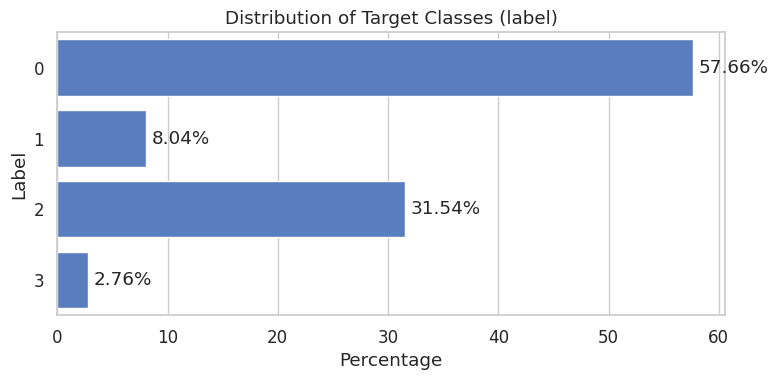

In [12]:
# Calculate percentage distribution
label_pct = train_df['label'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8,4))
ax = sns.barplot(
    x=label_pct.values,
    y=label_pct.index.astype(str),
)
plt.title("Distribution of Target Classes (label)")
plt.xlabel("Percentage")
plt.ylabel("Label")
# Annotate percentages
for i, v in enumerate(label_pct.values):
    ax.text(v + 0.5, i, f"{v:.2f}%", va='center')
plt.tight_layout()
plt.show()

## Vote Feature Distribution Analysis

I created few additional features from `upvote` and `downvote` feature.

- `log_upvote`, `log_downvote`: Log transformation compresses the long-tailed distributions of `upvote` and `downvote` and reduces skewness.
- `total_vote`: Measures the overall engagement level of a comment regardless of sentiment.
- `net_vote`: Represents the overall sentiment score of the community.
- `vote_ratio`: Measures relative positivity rather than absolute counts. The small constant (`0.001`) avoids division by zero.
- `controversiality`: Captures disagreement intensity. A comment is controversial when both upvotes and downvotes are high.

In [13]:
# Vote features
def extrate_vote_features(df):
    df = df.copy()
    df["log_upvote"] = np.log1p(df['upvote'])
    df["log_downvote"] = np.log1p(df['downvote'])
    
    df["total_vote"] = df["upvote"] + df["downvote"]
    df["net_vote"] = df["upvote"] - df["downvote"]
    df["vote_ratio"] = df["upvote"] / (df["downvote"] + 0.001)
    
    df["controversiality"] = (df["upvote"] * df["downvote"] / (df["total_vote"] + 0.001))
    return df

train_df = extrate_vote_features(train_df)
test_df = extrate_vote_features(test_df)

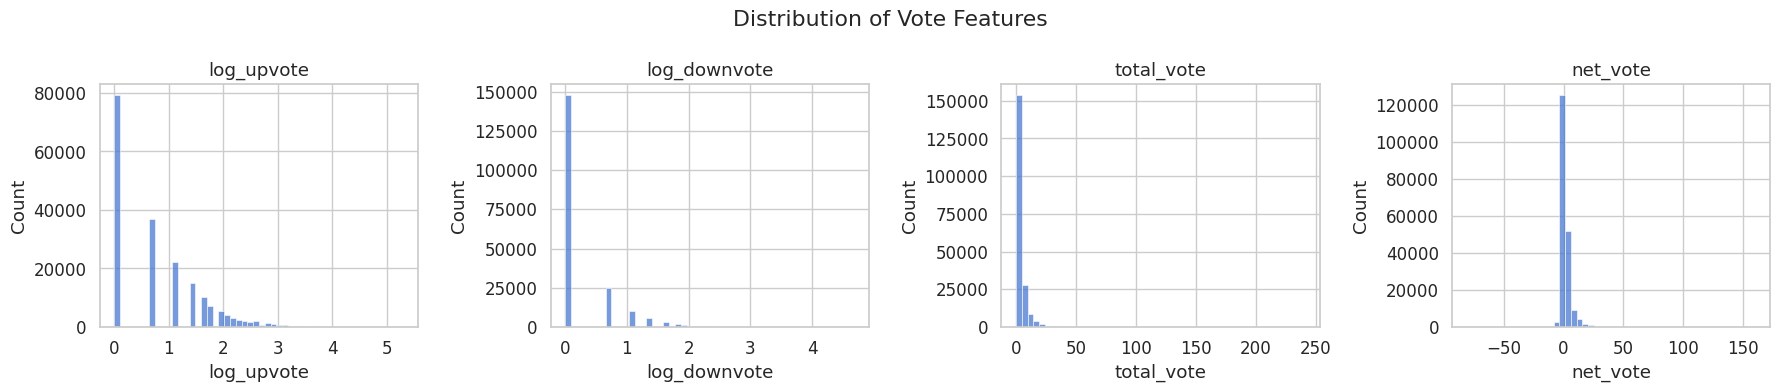

In [14]:
cols = ["log_upvote", "log_downvote", "total_vote", "net_vote"]
fig, axes = plt.subplots(1, 4, figsize=(18,4))
for i, col in enumerate(cols):
    sns.histplot(train_df[col], ax=axes[i], bins=50)
    axes[i].set_title(col)
fig.suptitle("Distribution of Vote Features")
plt.tight_layout()
plt.show()

The distributions reveal several important patterns:

- **Highly skewed vote distributions:** Most comments receive very few votes, while a small number receive significantly higher engagement.

- **Effect of logarithmic transformation:** Applying the `log1p` transformation to `upvotes` and `downvotes` compresses the scale and makes the distributions more interpretable. Without this transformation, the heavy-tailed distribution would dominate the feature space.

- **Low engagement for the majority of comments:** The `total_vote` distribution shows that most comments receive fewer than 10 total votes, indicating that high-engagement comments are relatively rare.

- **Net vote centered around zero:** The `net_vote` distribution clusters near zero, suggesting that many comments receive either balanced reactions or very few votes overall.

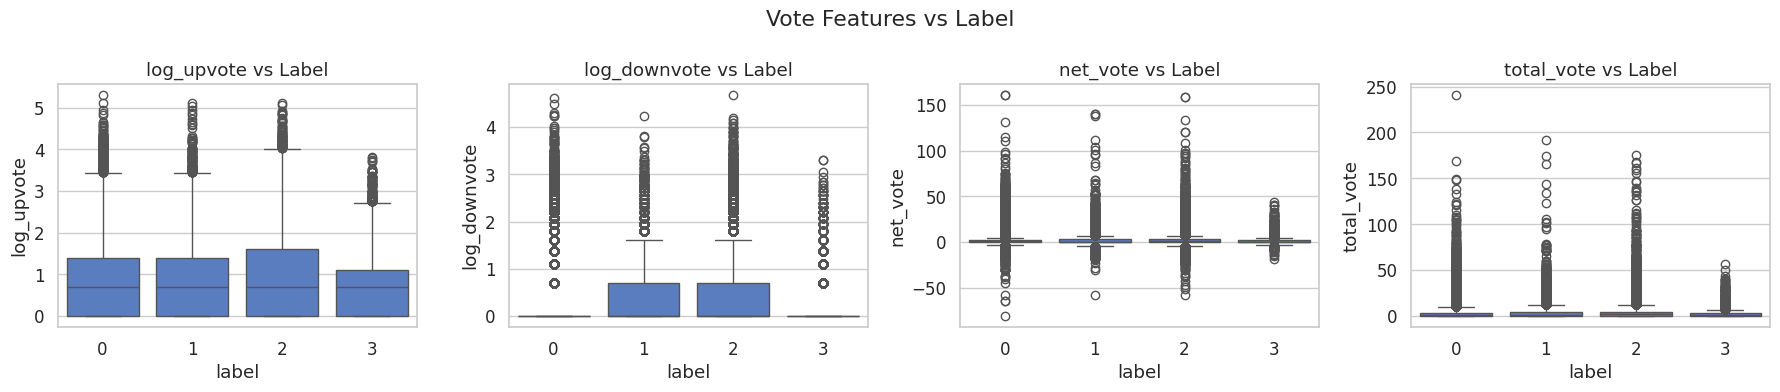

In [15]:
vote_features = ["log_upvote", "log_downvote", "net_vote", "total_vote"]
fig, axes = plt.subplots(1, len(vote_features), figsize=(18,4))
for ax, col in zip(axes, vote_features):
    sns.boxplot(data=train_df, x="label", y=col, ax=ax)
    ax.set_title(f"{col} vs Label")
fig.suptitle("Vote Features vs Label")
plt.tight_layout()
plt.show()

- The distributions of `log_upvote` show noticeable variation across labels, suggesting that some comment categories tend to receive more positive engagement than others.

- `log_downvote` values vary across labels as well, indicating that certain comment types may trigger stronger negative reactions.

- `net_vote` appears to be centered around zero for most labels, but the spread differs slightly across classes.

- `total_vote` distributions indicate that higher engagement comments appear in multiple label categories, although most comments still receive very few votes.

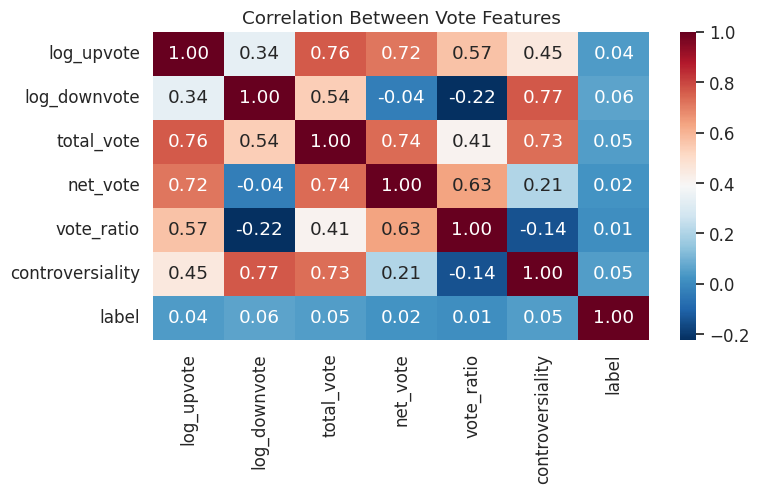

In [16]:
vote_corr_features = [
    "log_upvote", "log_downvote", "total_vote", "net_vote",
    "vote_ratio", "controversiality", "label"
]

plt.figure(figsize=(8,4))
sns.heatmap(
    train_df[vote_corr_features].corr(),
    annot=True,
    cmap="RdBu_r",
    fmt=".2f"
)
plt.title("Correlation Between Vote Features")
plt.show()

The correlation between vote features and the target label is relatively small (around 0.01–0.06). This indicates that vote-based features alone are not strong predictors of the label.

## Comment Features Analysis

To better understand the structural properties of the text data, we extract several basic features from the comment content:

- `char_count` – total number of characters in the comment
- `word_count` – number of words in the comment
- `avg_word_len` – average length of words within the comment

These features provide insights into the overall length and linguistic structure of the comments.

In [17]:
def extract_text_features(df):
    df = df.copy()

    df["char_count"] = df["comment"].str.len()
    df["word_count"] = df["comment"].str.split().str.len()
    df["avg_word_len"] = df["char_count"] / (df["word_count"] + 1)

    return df

train_df = extract_text_features(train_df)
test_df = extract_text_features(test_df)

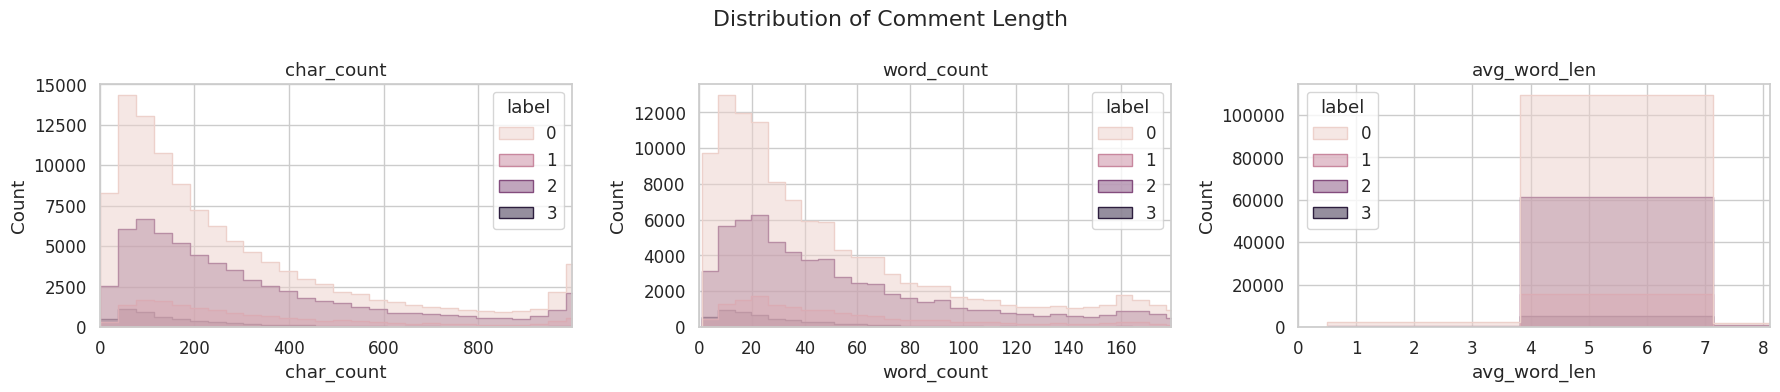

In [18]:
cols = ["char_count", "word_count", "avg_word_len"]
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, col in zip(axes, cols):
    sns.histplot(data=train_df, x=col, hue='label', bins=50, ax=ax, alpha=0.5, element='step')
    ax.set_title(col)
    ax.set_xlim(0, train_df[col].quantile(0.99))
fig.suptitle("Distribution of Comment Length")
plt.tight_layout()
plt.show()

The histograms above show the distribution of comment length features across the training dataset.

- **Right-skewed distributions:** Both `char_count` and `word_count` exhibit right-skewed distributions. Most comments are relatively short, while a smaller subset contains significantly longer messages.

- **Majority of comments are concise:** The majority of comments fall within the lower ranges of character and word counts. This suggests that users typically write brief responses rather than long discussions.

- **Presence of long-tail comments:** A small number of comments contain very large character and word counts, indicating longer explanations or detailed arguments.

- **Stable average word length:** The `avg_word_len` distribution is concentrated within a narrow range, suggesting that the linguistic complexity of comments remains relatively consistent across the dataset.

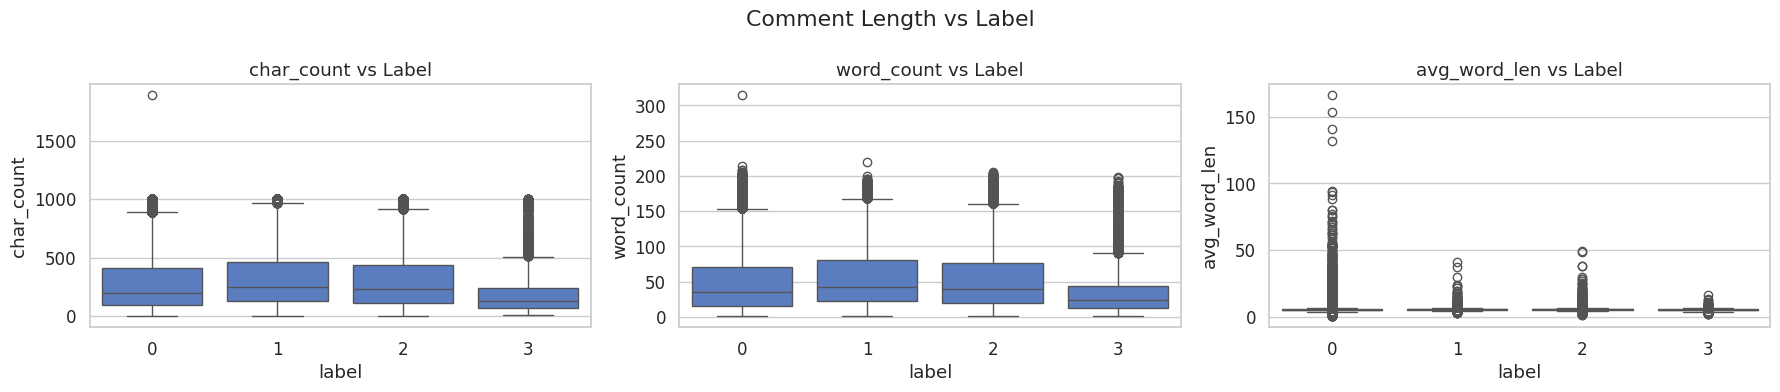

In [19]:
text_features = ["char_count", "word_count", "avg_word_len"]
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, col in zip(axes, text_features):
    sns.boxplot(data=train_df, x="label", y=col, ax=ax)
    ax.set_title(f"{col} vs Label")
fig.suptitle("Comment Length vs Label")
plt.tight_layout()
plt.show()

The boxplots above show how comment length features vary across different label categories.

- **Labels `1` and `2` tend to have slightly longer comments:** These labels show higher median values for both `char_count` and `word_count`, indicating that comments in these categories tend to contain more text.

- **Label `3` contains shorter comments on average:** Comments in this category appear shorter and more compact compared to other labels.

- **Substantial overlap between categories:** Despite slight differences in medians, the distributions of comment lengths across labels overlap significantly.

- **Presence of outliers:** Some comments contain unusually high word and character counts, indicating long-form discussions.

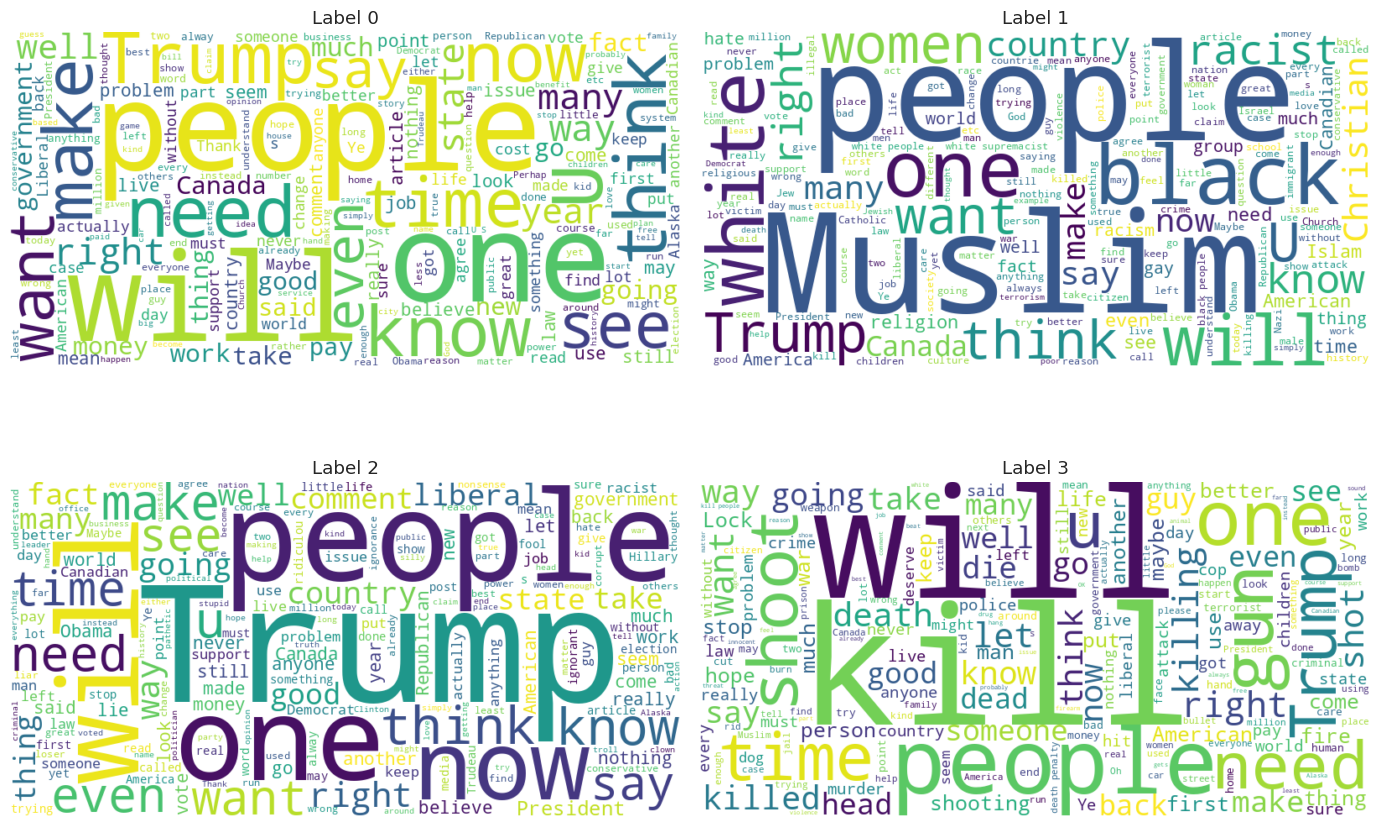

In [20]:
labels = sorted(train_df["label"].unique())
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for i, label in enumerate(labels):
    text = " ".join(train_df[train_df["label"] == label]["comment"].astype(str))

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=200
    ).generate(text)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"Label {label}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

- `Label 0`: The word cloud for Label 0 contains several general conversational terms such as: think, people, time, know, work

    These words suggest that comments in this category tend to involve general discussion or opinion-based statements. The vocabulary appears relatively neutral and broad, indicating that this label may correspond to common conversational content.

- `Label 1`: The Label 1 word cloud shows a strong presence of identity-related terms, including: men, women, black, white, racist, Islam

    This suggests that comments in this category often involve discussions related to identity, race, gender, or religion. The presence of these terms aligns with the identity indicator features analyzed earlier and may indicate that these comments reference specific social or demographic groups.

- `Label 2`: The vocabulary for Label 2 contains words related to discussion or argumentation also having geo-political view, such as: think, know, Trump, country, government

    These words suggest that comments in this category may represent reasoning or explanatory statements, where users express opinions, arguments, or counterarguments.

- `Label 3`: The Label 3 word cloud contains several words associated with violence or conflict, including: killing, death, gun, shooting, war

    This indicates that comments in this category may contain strong or aggressive language, potentially referring to violence or harmful actions.

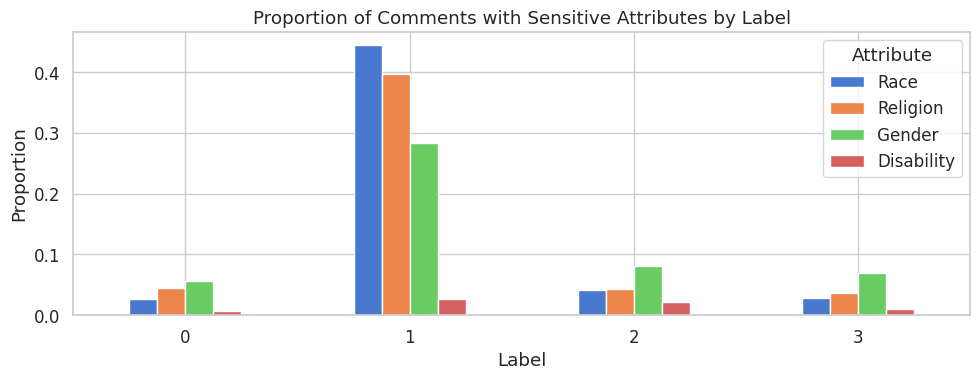

In [21]:
identity_cols = ['race_exists', 'religion_exists', 'gender_exists', 'disability']
sensitive_by_label = train_df.groupby('label')[identity_cols].mean()

fig, ax = plt.subplots(figsize=(10, 4))
sensitive_by_label.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title("Proportion of Comments with Sensitive Attributes by Label")
ax.set_ylabel("Proportion")
ax.set_xlabel("Label")
ax.legend(title="Attribute", labels=['Race', 'Religion', 'Gender', 'Disability'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Post-Level Comment Analysis

Each comment in the dataset is associated with a `post_id`, which represents the discussion thread or parent post to which the comment belongs. Analyzing comment behavior at the post level helps us understand how conversations are structured within the dataset.

In [22]:
print("No. of unique posts in Train set:", train_df["post_id"].nunique())
print("No. of unique posts in Test set :", test_df["post_id"].nunique())

No. of unique posts in Train set: 52
No. of unique posts in Test set : 45


This indicates that the dataset consists of a small number of discussion threads, each containing a large number of comments. Instead of many independent conversations, the data appears to be organized around a limited set of topics where users actively participate.

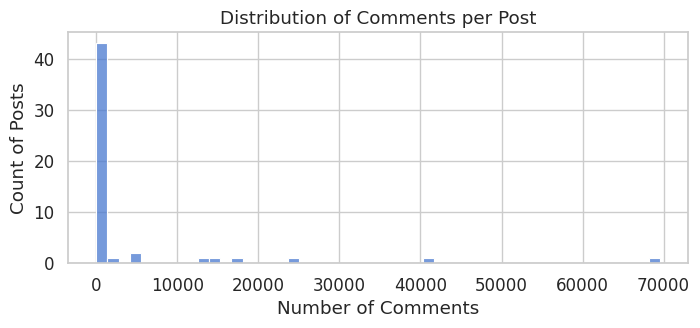

In [23]:
post_comment_counts = train_df.groupby("post_id").size()

plt.figure(figsize=(8,3))
sns.histplot(post_comment_counts, bins=50)
plt.title("Distribution of Comments per Post")
plt.xlabel("Number of Comments")
plt.ylabel("Count of Posts")
plt.show()

The histogram above shows the distribution of the number of comments associated with each post.

- The distribution is highly skewed, meaning a few posts receive a very large number of comments.

- Some posts attract tens of thousands of comments, indicating highly active discussion threads.

- Many posts have significantly fewer comments compared to the most active ones.

This pattern reflects typical online discussion behavior where a small number of topics attract large-scale engagement, while others generate smaller discussions.

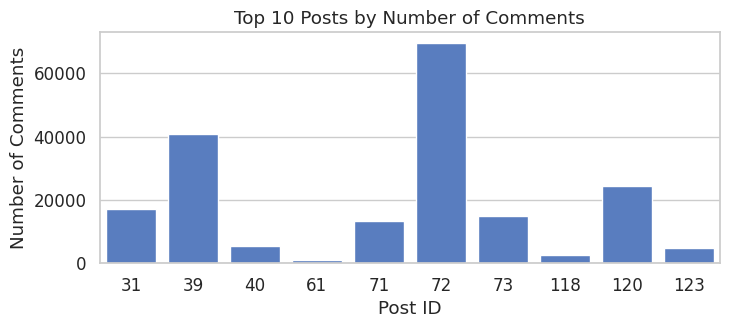

In [24]:
top_posts = post_comment_counts.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,3))
sns.barplot(y=top_posts.values, x=top_posts.index)
plt.title("Top 10 Posts by Number of Comments")
plt.ylabel("Number of Comments")
plt.xlabel("Post ID")
plt.show()

The bar chart shows the top 10 posts with the highest number of comments.

- Certain posts dominate the conversation, receiving extremely high numbers of comments.

- One post appears to have around 70,000 comments, significantly higher than others.

These posts represent highly active discussion threads, potentially related to controversial topics or widely debated issues. Such threads may contain diverse viewpoints and a wide range of comment categories.

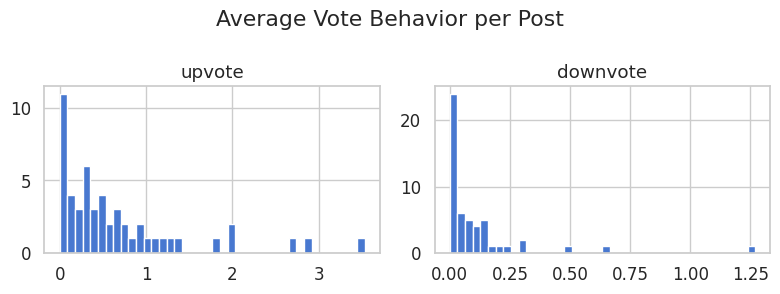

In [25]:
post_vote_stats = train_df.groupby("post_id")[["upvote","downvote"]].mean()

post_vote_stats.hist(figsize=(8,3), bins=40)
plt.suptitle("Average Vote Behavior per Post")
plt.tight_layout()
plt.show()

The histograms above show the distribution of the average upvotes and downvotes per post.

- Most posts have very low average `upvote` and `downvote` values, indicating limited engagement per individual comment.

- A few posts exhibit slightly higher average vote values, suggesting higher community interaction within those threads.

- The majority of posts remain clustered near low vote activity.

Although some discussion threads generate high numbers of comments, the average vote engagement per comment remains relatively low. This suggests that while discussions may be large, individual comments do not always receive significant voting interaction.

## Temporal Patterns

The `created_date` column carries temporal information. Different times of day or days of the week might see different types of comments.

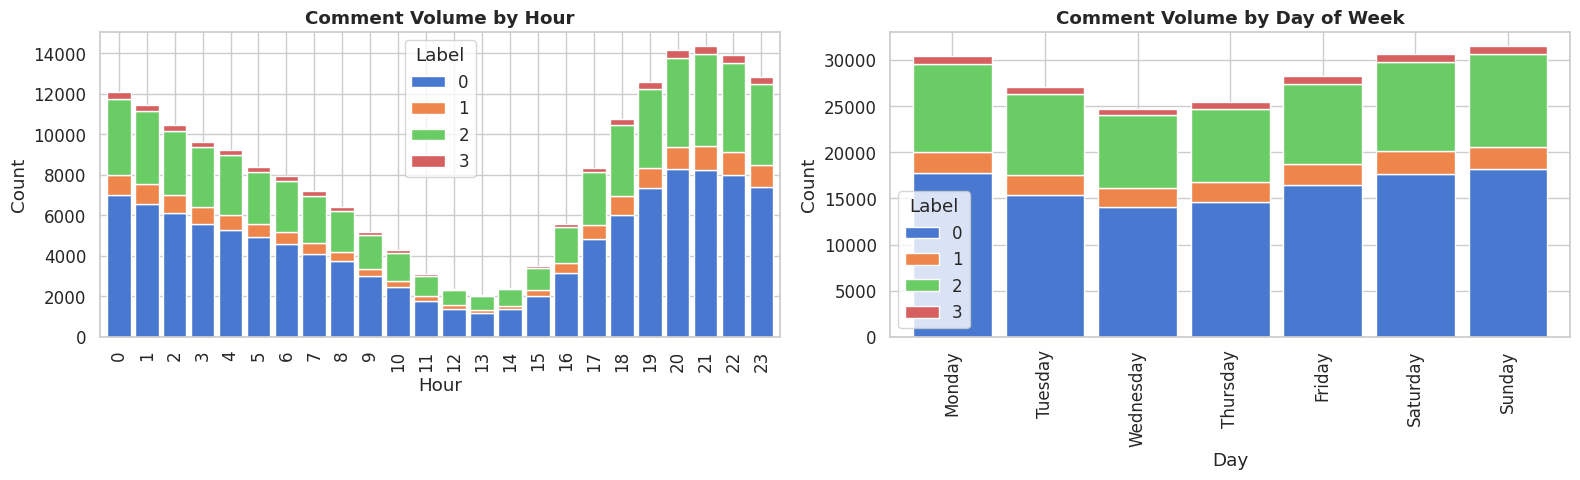

In [26]:
train_df['created_date'] = pd.to_datetime(train_df['created_date'])
train_df['hour'] = train_df['created_date'].dt.hour
train_df['dayofweek'] = train_df['created_date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Comments by hour
hour_label = train_df.groupby(['hour', 'label']).size().unstack(fill_value=0)
hour_label.plot(kind='bar', stacked=True, ax=axes[0], width=0.85, edgecolor='white')
axes[0].set_title("Comment Volume by Hour", fontweight='bold')
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")
axes[0].legend(title='Label')

# Comments by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_label = train_df.groupby(['dayofweek', 'label']).size().unstack(fill_value=0).reindex(day_order)
day_label.plot(kind='bar', stacked=True, ax=axes[1], width=0.85, edgecolor='white')
axes[1].set_title("Comment Volume by Day of Week", fontweight='bold')
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Count")
axes[1].legend(title='Label')

plt.tight_layout()
plt.show()

# Feature Enginearing

In [27]:
## Load the Datasets Again
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

## Shapes
print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

Train Dataset Shape: (198000, 15)
Test Dataset Shape: (102000, 14)


In [28]:
## Drop the missing comment (Only one)
train_df = train_df.dropna(subset=['comment']).reset_index(drop=True)

## Post-Level Features

By aggregating vote counts and comment frequency at the post level, we capture contextual information about the discussion thread a comment belongs to. A comment in a highly active or controversial thread may behave differently than one in a quiet thread.

In [29]:
## Function to get the post_id related features
def extract_post_features(df, col="post_id"):
    df = df.copy()

    post_stats = df.groupby("post_id").agg(
        post_count=("post_id", "size"),
        post_upvote_mean=("upvote", "mean"),
        post_upvote_sum=("upvote", "sum"),
        post_downvote_mean=("downvote", "mean"),
        post_downvote_sum=("downvote", "sum"),
    )

    df = df.merge(post_stats, on="post_id", how="left", sort=False)
    return df

## Datetime Features

We extract the hour of day and day of week as normalized continuous features, along with binary indicators for weekends and late-night hours. The hour is also bucketed into 4 bins (night, morning, afternoon, evening).

In [30]:
## Function to get the Datetime features from the created_date column
def extract_datetime_features(df, col="created_date"):
    df = df.copy()
    df[col] = pd.to_datetime(df[col])
    
    ## Normalize the dayofweek, hour features
    df['dayofweek'] = df[col].dt.dayofweek / 6.0
    df['hour'] = df[col].dt.hour / 23.0
    
    # Binned hour: 0=night(0-6), 1=morning(6-12), 2=afternoon(12-18), 3=evening(18-24)
    df['hour_bin'] = pd.cut(df[col].dt.hour, bins=[0,6,12,18,24], labels=[0,1,2,3], include_lowest=True).astype(int)
    
    ## Binary indicators
    df['is_weekend'] = df[col].dt.dayofweek.isin([5, 6]).astype(int)
    df['is_late_night'] = df["hour_bin"].isin([0,3]).astype(int)

    return df

## Text Features & Cleaning

This is the most feature-rich step. We extract two types of features from the `comment` text:

**Statistical features** (computed on raw text before cleaning):
- Character length, word count, unique word count, average word length
- Sentence count, capitalization ratio, exclamation/question ratios
- Presence of URLs, mentions, hashtags, repeated punctuation

**Lexicon-based features** (computed after cleaning):
- Positive/negative word counts using curated lexicons
- Profanity count, hate word count, insult count, identity word count
- Negation count (important for sentiment inversion)
- A simple sentiment score (positive - negative word counts)

**Text cleaning** includes lowercasing, contraction expansion, HTML/URL removal, punctuation stripping, and optional light stemming.

In [31]:
# Decontracting words
# https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
# https://stackoverflow.com/a/19794953
contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
}

In [32]:
## Function to get the text based features from the comment column
url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')
whitespace_pattern = re.compile(r'\s+')
punct_table = str.maketrans('', '', string.punctuation)

POS_WORDS = {
    "good","great","nice","love","awesome","amazing","happy","excellent",
    "wonderful","cool","best","fantastic","positive","brilliant"
}
NEG_WORDS = {
    "bad","terrible","hate","awful","worst","stupid","idiot","dumb",
    "nonsense","trash","garbage","useless","annoying","pathetic"
}
PROFANITY = {
    "fuck","shit","bitch","bastard","asshole","idiot","moron",
    "dumbass","fucking","bullshit","crap"
}
HATE_WORDS = {
    "racist","sexist","bigot","supremacy","nazi",
    "terrorist","degenerate","subhuman"
}
NEGATIONS = {"not","no","never","none","nobody","nothing"}
INSULT_WORDS = {"idiot","stupid","moron","dumb","loser","clown","trash"}
IDENTITY_WORDS = {
    "black","white","asian","muslim","christian",
    "jew","woman","man","gay","trans","disabled"
}

## Function to count the number of words from a given lexicon in the text
def count_words(text, lexicon):
    words = text.lower().split()
    return sum(1 for w in words if w in lexicon)

## Simple light stemming function to remove common suffixes
def light_stem(word):
    suffixes = ['ing', 'edly', 'edly', 'ed', 'ly', 's']
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[:-len(suffix)]
    return word

def clean_text(text, do_stemming=False):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()

    ## Replace common symbols with words
    text = text.replace('%', ' percent')
    text = text.replace('$', ' dollar ')
    text = text.replace('₹', ' rupee ')
    text = text.replace('€', ' euro ')

    ## Replace large numbers with abbreviations
    text = text.replace(',000,000,000 ', 'b ')      # 55 times
    text = text.replace(',000,000 ', 'm ')          # 265 times
    text = text.replace(',000 ', 'k ')              # 3626 times
    text = re.sub(r'([0-9]+)000', r'\1k', text)     # 4713 times

    ## Expand contractions
    contractions_re = re.compile('(%s)' % '|'.join(contractions.keys()))
    text = contractions_re.sub(lambda m: contractions[m.group(0)], text)

    ## Remove HTML tags and URLs
    text = html_pattern.sub('', text)
    text = url_pattern.sub('', text)

    ## Remove punctuation and extra whitespace
    text = text.translate(punct_table)
    text = whitespace_pattern.sub(' ', text).strip()

    ## Optional stemming
    if do_stemming:
        tokens = text.split()
        tokens = [light_stem(w) for w in tokens]
        text = " ".join(tokens)

    return text

In [33]:
def extract_text_features(df, col='comment', do_stemming=False):
    df = df.copy()
    
    # Statistical features
    df['char_len'] = df[col].apply(len)
    df['word_count'] = df[col].apply(lambda x: len(x.split()))
    df['unique_words'] = df[col].apply(lambda x: len(set(x.split())))
    df['avg_word_len'] = df['char_len'] / (df['word_count'] + 1)
    df['sentence_count'] = df[col].apply(lambda x: len(re.split(r'[.?!;]', x)))

    df['caps_ratio'] = df[col].apply(lambda x: sum(1 for c in x if c.isupper())) / (df['char_len'] + 1)
    df['exclamation_ratio'] = df[col].apply(lambda x: x.count("!")) / (df['sentence_count'] + 1)
    df['question_ratio'] = df[col].apply(lambda x: x.count("?")) / (df['sentence_count'] + 1)

    # Regex indicators
    df['has_url'] = df[col].apply(lambda x: int(bool(re.search(r'(http[s]?://|www\.)', x))))
    df['has_mention'] = df[col].apply(lambda x: int(bool(re.search(r'(^|\s)@\w+', x))))
    df['has_hashtag'] = df[col].apply(lambda x: int(bool(re.search(r'(^|\s)#\w+', x))))
    df['repeating_punct'] = df[col].apply(lambda x: max((len(m) for m in re.findall(r'([!?.]){2,}', x)), default=0))

    # Cleaning
    df[col] = df[col].apply(lambda x: clean_text(x, do_stemming))

    # Lexicon features
    df["pos_word_count"] = df[col].apply(lambda x: count_words(x, POS_WORDS))
    df["neg_word_count"] = df[col].apply(lambda x: count_words(x, NEG_WORDS))
    df["sentiment_score"] = df["pos_word_count"] - df["neg_word_count"]
    df["neg_ratio"] = df["neg_word_count"] / (df["word_count"] + 1)

    df["profanity_count"] = df[col].apply(lambda x: count_words(x, PROFANITY))
    df["has_profanity"] = (df["profanity_count"] > 0).astype(int)

    df["hate_word_count"] = df[col].apply(lambda x: count_words(x, HATE_WORDS))
    df["negation_count"] = df[col].apply(lambda x: count_words(x, NEGATIONS))
    df["insult_count"] = df[col].apply(lambda x: count_words(x, INSULT_WORDS))
    df["identity_count"] = df[col].apply(lambda x: count_words(x, IDENTITY_WORDS))

    return df

## Other Features (Votes, Sensitive Attributes)

We engineer several additional features:
- **Log-transformed votes** — Vote counts are highly skewed; log1p compresses the range.
- **Net vote and vote ratio** — Capture the balance between positive and negative reactions.
- **Controversiality score** — High when both upvotes and downvotes are high (divisive comments).
- **Sensitive attribute indicators** — Binary flags for whether race, religion, or gender references were detected.

In [34]:
## Get Other necessory features
def extract_other_features(df):
    df = df.copy()

    # Sensitive attributes
    identity_cols = ["race", "religion", "gender"]
    df[identity_cols] = df[identity_cols].fillna('none')
    for col in identity_cols:
        df[col + "_exists"] = (df[col] != "none").astype(int)
    df = df.drop(columns=identity_cols)
    
    df['disability'] = df['disability'].astype(int)
    df['sensitive_count'] = (df[["race_exists", "religion_exists", "gender_exists"]].astype(int).sum(axis=1) + df['disability'])
    df['any_sensitive'] = (df['sensitive_count'] > 0).astype(int)

    # Vote features
    df["log_upvote"] = np.log1p(df['upvote'])
    df["log_downvote"] = np.log1p(df['downvote'])

    df["total_vote"] = df["upvote"] + df["downvote"]
    df["net_vote"] = df["upvote"] - df["downvote"]
    df["vote_ratio"] = df["upvote"] / (df["downvote"] + 0.001)

    df["controversiality"] = (df["upvote"] * df["downvote"] / (df["total_vote"] + 0.001))

    return df

# Final Pipeline Construction

In [35]:
## Character based text vectorizer with 20k features
tfidf_char_vectorizer = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(3, 5),
    analyzer='char_wb',    ## Vectorize based on characters n-grams only from text inside word boundaries
    lowercase=True,
    min_df=5,              ## Ignore terms that have a document frequency strictly lower than 5
    max_df=0.9             ## Ignore terms that have a document frequency strictly higher than 90%
)

## Word based text vectorizer with 20k features cliped to 5k
tfidf_word_vectorizer = make_pipeline(
    TfidfVectorizer(
        analyzer='word',           ## Word based vectorization
        lowercase=True,
        strip_accents='unicode',   ## Use NFKD normalization from.
        ngram_range=(1, 2),
        
        # Vocabulary control
        max_features=20_000,
        min_df=3,                  ## Ignore terms that have a document frequency strictly lower than 3
        max_df=0.9,                ## Ignore terms that have a document frequency strictly higher than 90%
        token_pattern=r'(?u)\b[a-zA-Z]{2,}\b',
        
        # Term weighting
        sublinear_tf=True,         ## Replace tf with 1 + log(tf).
    ),
    SelectKBest(chi2, k=5000)
)

In [36]:
std_scale_features = [
    ## Default features
    'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2',
    ## Text features
    'char_len', 'word_count', 'unique_words', 'avg_word_len', 'sentence_count',
    'pos_word_count', 'neg_word_count', 'sentiment_score', 'profanity_count',
    'hate_word_count', 'negation_count', 'insult_count', 'identity_count',
    ## Post features
    'post_count', 'post_upvote_mean', 'post_upvote_sum', 'post_downvote_mean',
    'post_downvote_sum',
    ## Datetime features
    'hour_bin',
    ## Sensitive attributes
    'sensitive_count',
    ## Vote features (Default + Engineered)
    'upvote', 'downvote', 'log_upvote', 'log_downvote', 'total_vote', 'net_vote',
    'vote_ratio', 'controversiality',
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num_std_scaler', StandardScaler(), std_scale_features),
        ('text_char_tfidf', tfidf_char_vectorizer, 'comment'),
        ('text_word_tfidf', tfidf_word_vectorizer, 'comment'),
    ],
    remainder='passthrough',
    verbose_feature_names_out=True,
    # sparse_threshold=0
)

pipeline = Pipeline(steps=[
    ('text_clean', FunctionTransformer(
        extract_text_features, kw_args={'col': 'comment', 'do_stemming': False}
    )),
    ('post_features', FunctionTransformer(
        extract_post_features, kw_args={'col': 'post_id'}
    )),
    ('datetime_features', FunctionTransformer(
        extract_datetime_features, kw_args={'col': 'created_date'}
    )),
    ('other_features', FunctionTransformer(extract_other_features)),
    ('remove_columns', FunctionTransformer(
        lambda X: X.drop(columns=["created_date", "post_id"], errors="ignore")
    )),
    ('preprocessor', preprocessor)
])

print("Pipeline constructed successfully.")
print("\nPipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name:<20}: {type(step).__name__}")

Pipeline constructed successfully.

Pipeline steps:
  text_clean          : FunctionTransformer
  post_features       : FunctionTransformer
  datetime_features   : FunctionTransformer
  other_features      : FunctionTransformer
  remove_columns      : FunctionTransformer
  preprocessor        : ColumnTransformer


---

# Model Training & Evaluation

## Train/Validation Split

We use stratified splitting to ensure each label class is proportionally represented in both train and validation sets.

In [37]:
# Prepare Training and Validation Set
# Using 20% of the dataset as Validation Set
X = train_df.drop(columns=["label"])
y = train_df["label"]
test_size = 0.2

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=test_size,
    random_state=42,
    stratify=y
)

## Sanity checks to ensure that the splits are correct
assert X_train.shape[0] == y_train.shape[0], "Mismatch in number of samples between X_train and y_train"
assert X_val.shape[0] == y_val.shape[0], "Mismatch in number of samples between X_val and y_val"

## Print the distribution of labels in the training and validation sets
## to ensure they are similar (stratification worked)
print_distribution(X_train, y_train, f"Training Set ({(1-test_size)*100}%)", 60, 44)
print()
print_distribution(X_val, y_val, f"Validation Set ({test_size*100}%)", 60, 44)

Training Set (80.0%)                     Shape: (158399, 14)
Distribution of labels:

0     57.66%  [=========================                   ]
1     08.04%  [===                                         ]
2     31.54%  [=============                               ]
3     02.76%  [=                                           ]

Validation Set (20.0%)                    Shape: (39600, 14)
Distribution of labels:

0     57.66%  [=========================                   ]
1     08.04%  [===                                         ]
2     31.54%  [=============                               ]
3     02.76%  [=                                           ]


In [38]:
# Transform the data to save time and compute
# with Timer("Pipeline Fit on Train Set"):
#     pipeline.fit(X_train, y_train)

# with Timer("Transforming"):
#     X_train_tf = pipeline.transform(X_train)
#     X_val_tf = pipeline.transform(X_val)

# print(f"\nShape: {X_train_tf.shape}")
# print(f"Memory: ~{X_train_tf.data.nbytes / 1e6:.1f} MB (sparse)")

By experimenting with various models, this is the result of some of the top models:

```
Logistic        : F1 Score = 0.783,  Accuracy = 0.903  and  RMSE = 0.519
SGD Classifier  : F1 Score = 0.666,  Accuracy = 0.879  and  RMSE = 0.579
Linear SVC      : F1 Score = 0.667,  Accuracy = 0.790  and  RMSE = 0.876
Random Forest   : F1 Score = 0.740,  Accuracy = 0.886  and  RMSE = 0.556
MLP Classifier  : F1 Score = 0.770,  Accuracy = 0.889  and  RMSE = 0.557
XGB Classifier  : F1 Score = 0.790,  Accuracy = 0.909  and  RMSE = 0.475
LGBM Classifier : F1 Score = 0.803,  Accuracy = 0.911  and  RMSE = 0.478
```

All these models were trained on around `20k` rows and on a weaker transformed dataset for speedup. This gave a better overview of the performance of different models on the dataset.

From this Experiment, we can see that the top three best models are:
- LGBM Classifier:  F1 Score = 0.803
- XGB Classifier:   F1 Score = 0.790
- Logistic regression:  F1 Score = 0.783

So, we are using these three models for further experimentations and hope to get a better result.

## Logistic Regression

In [39]:
# log_reg = LogisticRegression(max_iter=1000, random_state=42)

# print("Fitting Logistic Regression on training set...")
# with Timer("LR Fit "):
#     log_reg.fit(X_train_tf, y_train)

# with Timer("Predict"):
#     y_val_pred_log = log_reg.predict(X_val_tf)

# ## Saving the model to disk
# joblib.dump(log_reg, "lr_base.pkl")
# del log_reg

# print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred_log))
# print("Validation F1 Score:", f1_score(y_val, y_val_pred_log, average='macro'))
# print("\nClassification Report:\n", classification_report(y_val, y_val_pred_log))

Training Logistic Regression model on 80% of the training dataset with the powerfull preprocessing did improved the F1 Score from 0.783 to 0.797

## Light GBM Classifier

In [40]:
# n_classes = len(np.unique(y_train))
# lgbm = LGBMClassifier(
#     objective="multiclass",
#     num_class=n_classes,
    
#     n_estimators=500,
#     learning_rate=0.05,
#     num_leaves=41,
    
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1
# )

# print("Fitting Light GBM on training set...")
# with Timer("LGBM Fit"):
#     lgbm.fit(X_train_tf, y_train)

# with Timer("Predict "):
#     y_val_pred_lgbm = lgbm.predict(X_val_tf)

# ## Saving the model to disk
# joblib.dump(lgbm, "lgbm_base.pkl")
# del lgbm

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_lgbm))
# print("Validation F1 Score:", f1_score(y_val, y_val_pred_lgbm, average='macro'))
# print("\nClassification Report:\n", classification_report(y_val, y_val_pred_lgbm))

Training Light GBM on the entire 80% of the dataset improved the model a lot, from 0.803 to 0.822. And also this gave us the best result so far.

## XG Boost Classifier

In [41]:
# n_classes = len(np.unique(y_train))
# xgb = XGBClassifier(
#     objective="multi:softprob",
#     num_class=n_classes,
    
#     n_estimators=1000,
#     learning_rate=0.05,
    
#     tree_method="hist",
#     device='cuda',
#     grow_policy='lossguide', 

#     max_leaves=31,
#     max_depth=0,
#     reg_alpha=0.1,
#     reg_lambda=1.0,
#     subsample=0.8,
    
#     random_state=42,
#     n_jobs=-1,
#     verbosity=1
# )

# print("Fitting XG Boost on training set...")
# with Timer("XGB Fit"):
#     xgb.fit(X_train_tf, y_train)

# with Timer("Predict"):
#     y_val_pred_xgb = xgb.predict(X_val_tf)

# ## Saving the model to disk
# joblib.dump(xgb, "xgb_base.pkl")
# del xgb

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
# print("Validation F1 Score:", f1_score(y_val, y_val_pred_xgb, average='macro'))
# print("\nClassification Report:\n", classification_report(y_val, y_val_pred_xgb))

XG Boost model also improved from 0.790 to 0.804

## Model Comparison

---

# Hyperparameter Tuning

So, among all the above model, `Light GBM` is the most performent model. So, I've tried doing Hyper-Parameter Tuning on this model.

I had tried Grid Search CV, Randomized Search CV, as well as Optuna (Locally for experimenting), but faced some issues:

- Training on large set with full feature space was taking so long (Like more than 12hr).
- Training on smaller set or with smaller feature space actually boosts the training speed, but the results were disapointing.
- Couldn't perform the HPT on cloud platform as well, (Kaggle/Colab has 12hr of runtime limit, Other platforms are quite expensive)
- Doing the HPT on my Laptop for so long was not practical as well.

So, I have tried a Randomized Search CV below, ran it on Kaggle (took >6hr). Tried it on a very small set (20k) with full feature space, for only 3 iteration with 2 cross validation (total of 6 fits).

In [42]:
## Tune on small set.
# sample_size = 20_000
# idx = np.random.RandomState(42).choice(X_train_tf.shape[0], sample_size, replace=False)

# X_train_small = X_train_tf[idx]
# y_train_small = y_train.iloc[idx] if hasattr(y_train, "iloc") else y_train[idx]

# # Base model
# n_classes = len(np.unique(y_train))
# lgbm = LGBMClassifier(
#     objective="multiclass",
#     num_class=n_classes,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1
# )

# # Parameters to tune
# param_dist = {
#     "n_estimators": [300, 500, 700],
#     "learning_rate": np.linspace(0.03, 0.1, 5),
#     "num_leaves": [31, 63, 127],
#     "max_depth": [-1, 10, 20],
#     "subsample": [0.7, 0.8, 0.9, 1.0],
# }

# search = RandomizedSearchCV(
#     lgbm,
#     param_dist,
#     n_iter=3,
#     scoring="f1_macro",
#     cv=2,
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# search.fit(X_train_small, y_train_small)

# print("Best Score:", search.best_score_)
# print("Best Params:", search.best_params_)

# best_params = search.best_params_
# best_lgbm = LGBMClassifier(
#     objective="multiclass",
#     num_class=n_classes,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1,
#     **best_params
# )

# with Timer("Training final LGBM on full dataset"):
#     best_lgbm.fit(X_train_tf, y_train)

# with Timer("Predicting"):
#     y_val_pred = best_lgbm.predict(X_val_tf)

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
# print("Validation F1 Score:", f1_score(y_val, y_val_pred, average='macro'))
# print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

In [43]:
# n_classes = len(np.unique(y_train))
# xgb = XGBClassifier(
#     objective="multi:softprob",
#     num_class=n_classes,
    
#     n_estimators=1000,
#     learning_rate=0.05,
    
#     tree_method="hist",
#     device='cuda',
#     grow_policy='lossguide', 

#     max_leaves=31,
#     max_depth=0,
#     reg_alpha=0.1,
#     reg_lambda=1.0,
#     subsample=0.8,
    
#     random_state=42,
#     n_jobs=-1,
#     verbosity=1
# )

# param_grids = {
#     'sampling_method': ['gradient_based'],
#     'n_estimators':    [500, 700, 1000, 1200, 1500],
#     'max_depth':       [0, 1, 2, 3, 4],
#     'max_bin':         [16, 32, 64, 128],
#     'learning_rate':   [0.01, 0.05, 0.1, 0.3],
#     'max_leaves':      [31, 40, 50],
#     'subsample':       [0.3, 0.5, 0.7, 0.8],
#     'colsample_bytree': [0.3, 0.5, 0.7],
#     'reg_alpha':       loguniform(1e-3, 10),
#     'reg_lambda':      loguniform(1e-3, 10),
# }

# search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_grids,
#     n_iter=20,
#     scoring='f1_macro',
#     cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=42),
#     random_state=42,
#     n_jobs=1,
#     verbose=2,
#     refit=True,
# )

# with Timer("HPT Fit"):
#     search.fit(X_train_tf, y_train)

# print(f"\nBest CV F1 (macro): {search.best_score_:.4f}")
# print(f"\nBest parameters:")
# for k, v in search.best_params_.items():
#     print(f"  {k}: {v}")

# ## Validate
# tuned_model = search.best_estimator_
# y_val_pred_tuned = tuned_model.predict(X_val_tf)

# if hasattr(y_val_pred_tuned, 'flatten'):
#     y_val_pred_tuned = y_val_pred_tuned.flatten()

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_tuned))
# print("Validation F1 Score:", f1_score(y_val, y_val_pred_tuned, average='macro'))
# print("\nClassification Report:\n", classification_report(y_val, y_val_pred_tuned))

In [44]:
best_params = {
    'sampling_method':  'gradient_based',
    'n_estimators':     1200,
    'max_depth':        0,
    'max_bin':          32,
    'learning_rate':    0.05,
    'max_leaves':       40,
    'subsample':        0.7,
    'colsample_bytree': 0.5,
    'reg_alpha':        0.0010672476836323724,
    'reg_lambda':       0.0012366582530130832,
}

n_classes = len(np.unique(y_train))
xgb_tuned = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    
    tree_method="hist",
    device='cuda',
    grow_policy='lossguide', 
    
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    **best_params,
)

best_xgb_pipe = make_pipeline(pipeline, xgb_tuned)

On a glance, it appears to be improving the result so slightly from 0.82152 to 0.82224. But submitting this model reduced the public leaderboard score. So, it might be overfitting.

Ultimately, I had to rely on manual Hyper parameter tuning.

In [45]:
## Light GBM Classifier With HPT (Failed Attempt)
# best_params = {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1}

# n_classes = len(np.unique(y_train))
# best_lgbm = LGBMClassifier(
#     objective="multiclass",
#     num_class=n_classes,
#     random_state=42,
#     n_jobs=-1,
#     verbose=-1,
#     **best_params,
# )
# best_lgbm_pipe = make_pipeline(pipeline, best_lgbm)

## Final Submission

In [46]:
final_pipe = best_xgb_pipe

full_train_X = train_df.drop(columns=['label'])
full_train_y = train_df['label']

print(f"Retraining on full dataset ({len(full_train_X):,} samples)...")
with Timer("Final Model Fit"):
    final_pipe.fit(full_train_X, full_train_y)

Retraining on full dataset (197,999 samples)...
[Final Model Fit] Time taken: 7m 10.53s


In [47]:
print("Generating Prediction...")
y_test_pred = final_pipe.predict(test_df)

submission = pd.DataFrame({
    'ID': range(1, test_df.shape[0] + 1),
    'label': y_test_pred
})
submission.to_csv('submission.csv', index=False)

print('Submission Done!')
print(f"Submission shape: {submission.shape}")
print(f"\nPredicted label distribution:")
print(submission['label'].value_counts().sort_index())
submission.head(10)

Generating Prediction...
Submission Done!
Submission shape: (102000, 2)

Predicted label distribution:
label
0    56892
1     8123
2    34915
3     2070
Name: count, dtype: int64


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
5,6,0
6,7,1
7,8,0
8,9,0
9,10,2


# Appendix (Milestones)

In [48]:
## Milestone 1

## Q.1. What is the shape of the training dataset?
# train_df.shape # (198000, 15)

## Q.2. How many columns are present in the test dataset?
# test_df.shape[1] # 14

## Q.3. How many columns in the training dataset have object data type?
# train_df.dtypes.value_counts()[np.dtype('O')] # 5

## Q.4. How many numerical columns are present in the training dataset?
# train_df.dtypes.value_counts()[np.dtype('int')] # 9

## Q.5. Which of the following columns is of boolean type?
# train_df.dtypes[train_df.dtypes == 'bool'].index # disability

## Q.6. Which of the following columns have missing values?
# train_df.isnull().sum()[train_df.isnull().sum() > 0].index # 'race', 'religion', 'gender', 'comment'

## Q.7. How many distinct target classes are present in the dataset?
# train_df["label"].nunique() # 4

## Q.8. What percentage of the dataset approximately belongs to label 0?
# train_df["label"].value_counts(normalize=True)[0] # ~58%

## Q.9. What is the median number of upvotes per comment?
# train_df["upvote"].median() # 1

## Q.10. Which numerical feature shows the largest maximum value?
# train_df.describe().T['max'].idxmax() # 'if_1'

## Q.11. What is the minimum value of if_2?
# train_df["if_2"].min() # 3

In [49]:
## Milestone 2

## Q.1. In the context of text preprocessing for NLP, which condition must be checked in addition to NaN values when assessing missingness in the comment column of train.csv?
## Presence of empty or whitespace-only strings


## Q.2. Convert the created_date column into datetime objects. Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string.
# pd.to_datetime(train_df['created_date']).dt.month.value_counts().idxmax() # np.int32(5) = 'may'


## Q.3. Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?
# (train_df['emoticon_1'] + train_df['emoticon_2'] + train_df['emoticon_3']).max() # 60


## Q.4. Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings).
# train_df[train_df['label'] == 3].str.len().median() # 128.0


## Q.5. If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the resulting scaled value for an observation that originally had exactly 10 upvotes?

# scaler = MinMaxScaler()
# scaler.fit(train_df[['upvote']])
# scaler.transform([[10]]) # array([[0.04975124]])


## Q.6. What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? (Round your answer to 2 decimal places).
# train_df[train_df['label'] == 1].str.split().str.len().mean() # np.float64(57.23344641286594)


## Q.7. How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive.
# train_df['comment'].str.lower().str.count('trump').sum() # np.float64(37095.0)


## Q.8. Take the comment at the very first row (index 0).
## - Remove all punctuation.
## - Consider the following words as stop words and remove the same : ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
## How many words are left in the text after these two operations?

# import string
# c = train_df['comment'][0]
# stop_words =  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
# c = c.translate(str.maketrans('', '', string.punctuation))
# c = c.split()
# c = [word for word in c if word not in stop_words]
# len(c) # 13


## Q.9. Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number of unique tokens in the dataset and enter the value.

# cvt = CountVectorizer(lowercase=True, token_pattern=r'\b\w+\b')
# cvt.fit(train_df['comment'])
# len(cvt.vocabulary_) # 171390


## Q.10. Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2).
## How many TF-IDF features are generated using this configuration?

# tfidf = TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1,2))
# tfidf.fit(train_df['comment'])
# len(tfidf.vocabulary_) # 132974